# Probabilidad y Estadística - Tecnicatura en desarrolo de software - IFTS Nº 29



**Profesora: Daniela Parada**

**Comisión: D**


---



**Grupo: El Quinto Elemento**

**Integrantes**  




>Clausi, Damian

>Descosido, Cristian

> Gill, Cesar Antonio          

                  
                  




# Trabajo de simulación 3

Para el último trabajo de simulación, vamos a hacer un análisis de datos a partir de la encuesta de salarios de Sysarmy del segundo trimestre de 2023.

Los datos oficiales se encuentran [acá](https://docs.google.com/spreadsheets/d/1-59q6epgnkOKnFsyi3uOrC72pTMJz60fvmAOvnxP-no/edit#gid=1719689619). Por si en algún momento el enlace se cae o cambia de ubicación, una versión descargada el 6 de agosto de 2023 puede encontrarse [acá](https://docs.google.com/spreadsheets/d/15FZw8C6aAnzNl1K1dA5t7SlNKclD0j3_/edit?usp=sharing&ouid=104217074840737622126&rtpof=true&sd=true).

Las consignas de este trabajo no son tan dirigidas como las de los trabajos anteriores, pues en el análisis de datos, siempre hay libertad y margen para la creatividad y la producción personal. Sin embargo, les compartimos algunas pautas de lo que debe tener, como mínimo, este trabajo.

Pautas generales y **OBLIGATORIAS** para la aprobación de la entreg:

*   Debe replicarse, como mínimo, un análisis similar al aquí presentado para los datos del 2020.
*   Debe escribirse en formato "informe", es decir, no se trata de exhibir código y gráficos, sino de explicar qué se observa y por qué es relevante observar eso. El informe es requisito **excluyente**. No se aprueba el trabajo de simulación sin él. Este informe puede incluirse en el mismo notebook SIEMPRE Y CUANDO tenga la estructura de un informe (**NO** código comentado), o puede entregarse en un word/pdf adicional.
*   El trabajo debe contener, como mínimo, **una conjetura que sea sometida a prueba y de la que se exhiba alguna conclusión fundamentada**, como se hizo en el caso de los datos de 2020 para el salario medio bruto por género y para hombres y mujeres con nivel universitario completo. Por ejemplo, frente a la pregunta de si el salario medio de mujeres y hombres es igual, podríamos poner en práctica lo que estudiamos en las postas 4 y 5 para, de alguna forma, darnos una idea de cuán probable es observar lo que efectivamente estamos observando. Este es un "coqueteo" con la estadística inferencial, que no estudiamos formalmente en la materia, pero que es válido comenzar a encarar con todo lo que hemos estudiado.

El resto de la producción queda a criterio de los grupos. Esperamos que haya un interés genuino en tratar de extraer información a partir de estos datos. No solo por el desafío intelectual que representa, sino porque, además, se tratan de datos que pueden servirles a ustedes para la toma de decisiones profesionales sobre su incorporación al mundo IT. ¡Muchos éxitos!

#INICIO


Arrancamos el trabajo repliclando el análisis de datos del 2020 pero con los datos del segundo trimestre del 2023.


Como conjetura planteamos que un Desarrollador Cobol, no es una persona novel en la industria IT sino alguien con mucha experienica, pocos en su especie y que debería ganar en promedio mucho más que cualquier desarrollador entre 5 y 10 años de experiencia.

##ENCUESTA DE SALARIOS DEL SEGUNDO TRIMESTRE DEL 2023

Arrancamos cargando las librerias necesarias para este NoteBook

In [1]:
# Librerías
import io
import pandas as pd

pd.set_option('display.max_rows', 10)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
#El CSV lo subimos a github.
url = 'https://github.com/TDS-IFTS29/IFTS29_EPDS_Trabajo_Practico_3_CSV/raw/main/Sysarmy-2023-2.csv'
df = pd.read_csv(url)
# Con esta instrucción imprimimos las primeras 10 filas del dataset
df[0:9]

,estoy_trabajando_en,donde_estas_trabajando,dedicacion,tipo_de_contrato,ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local,ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local,pagos_en_dolares,si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron,recibis_algun_tipo_de_bono,a_que_esta_atado_el_bono,...,salir_o_seguir_contestando_sobre_las_guardias,tenes_guardias,cuanto_cobras_por_guardia,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,tengo_edad,me_identifico_genero,sueldo_dolarizado,seniority,_sal
0,Argentina,La Rioja,Part-Time,Staff (planta permanente),100000.0,134000.0,Mi sueldo está dolarizado (pero cobro en moned...,300,No,No recibo bono,...,NaN,NaN,NaN,NaN,NaN,38,Prefiero no decir,True,Senior,100000.0
1,Argentina,Córdoba,Full-Time,Staff (planta permanente),100000.0,800000.0,Cobro parte del salario en dólares,blue,No,Mix de las anteriores,...,NaN,NaN,NaN,NaN,NaN,26,Hombre Cis,True,Semi-Senior,100000.0
2,Argentina,Santa Fe,Part-Time,Freelance,100000.0,93000.0,Mi sueldo está dolarizado (pero cobro en moned...,200,No,No recibo bono,...,NaN,NaN,NaN,NaN,NaN,27,Hombre Cis,True,Junior,100000.0
3,Argentina,Tucumán,Part-Time,Staff (planta permanente),100000.0,100000.0,NaN,NaN,No,No recibo bono,...,Terminar encuesta,NaN,NaN,NaN,NaN,25,Hombre Cis,False,Junior,100000.0
4,Argentina,Mendoza,Full-Time,Tercerizado (trabajo a través de consultora o ...,100000.0,83000.0,NaN,NaN,No,No recibo bono,...,Terminar encuesta,NaN,NaN,NaN,NaN,22,Hombre Cis,False,Junior,100000.0
5,Argentina,Buenos Aires,Part-Time,Staff (planta permanente),100000.0,100000.0,NaN,NaN,No,No recibo bono,...,Terminar encuesta,NaN,NaN,NaN,NaN,38,Hombre Cis,False,Junior,100000.0
6,Argentina,Salta,Full-Time,Tercerizado (trabajo a través de consultora o ...,100000.0,95600.0,NaN,NaN,Un sueldo,Medio sueldo cada seis meses,...,NaN,NaN,NaN,NaN,NaN,31,Hombre Cis,False,Junior,100000.0
7,Argentina,San Luis,Full-Time,Staff (planta permanente),100000.0,83000.0,NaN,NaN,No,No recibo bono,...,NaN,NaN,NaN,NaN,NaN,27,Mujer Cis,False,Junior,100000.0
8,Argentina,Mendoza,Full-Time,Staff (planta permanente),100000.0,83000.0,NaN,NaN,No,No recibo bono,...,NaN,NaN,NaN,NaN,NaN,25,Mujer Cis,False,Junior,100000.0


El *dataframe df* que creamos tiene información de nuestros datos en filas y columnas.

Cada fila es un registro, es decir, una de las respuestas de la encuesta.
Cada columna es una variable. Algunas de esas variables son categóricas (como el género, el país o la ciudad), numéricas ordinales (como las de recomendación de la compañía), numéricas continuas (como el salario, la edad, la antigüedad en el puesto o los años de experiencia) o de otro tipo.
Con la instrucción *describe* podemos tener una rápida lectura de los estadísticos más importantes de cada una de las variables continuas del dataframe.

In [3]:
df.describe()

,ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local,ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local,de_que_fue_el_ajuste_total_acumulado,como_consideras_que_estan_tus_ingresos_laborales_comparados_con_el_semestre_anterior,que_tan_conforme_estas_con_tus_ingresos_laborales,anos_de_experiencia,antiguedad_en_la_empresa_actual,tiempo_en_el_puesto_actual,cuantas_personas_a_cargo_tenes,si_trabajas_bajo_un_esquema_hibrido_cuantos_dias_a_la_semana_vas_a_la_oficina,la_recomendas_como_un_buen_lugar_para_trabajar,que_tanto_estas_usando_copilotchatgpt_u_otras_herramientas_de_ia_para_tu_trabajo,cuanto_cobras_por_guardia,tengo_edad,_sal
count,5.422000e+03,5.212000e+03,5422.000000,5422.000000,5422.000000,5422.000000,5422.000000,5422.000000,5422.000000,5422.000000,5422.000000,5422.000000,1650.000000,5422.000000,5.422000e+03
mean,6.942213e+05,5.685870e+05,52.792536,2.624493,2.613611,7.788823,3.364994,2.386389,2.318148,0.702508,6.642198,1.918665,3334.709442,34.191442,6.942213e+05
std,6.078578e+05,6.967540e+05,976.415283,0.820268,0.861301,7.381146,4.806967,3.205716,9.138628,1.167027,2.792652,1.612024,18526.883258,9.948709,6.078578e+05
min,4.500000e+04,1.390000e+02,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,4.500000e+04
25%,3.200000e+05,2.750000e+05,10.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,5.000000,0.000000,0.000000,28.000000,3.200000e+05
50%,5.070000e+05,4.160000e+05,25.000000,3.000000,3.000000,5.000000,2.000000,2.000000,0.000000,0.000000,7.000000,2.000000,0.000000,33.000000,5.070000e+05
75%,8.200000e+05,6.000000e+05,40.000000,3.000000,3.000000,12.000000,4.000000,3.000000,1.000000,1.000000,8.000000,3.000000,0.000000,39.000000,8.200000e+05
max,4.500000e+06,2.229600e+07,50000.000000,4.000000,4.000000,46.000000,93.000000,30.000000,230.000000,5.000000,10.000000,5.000000,300000.000000,366.000000,4.500000e+06


En lo que sigue, vamos a estudiar el comportamiento de algunas variables de interés e iniciar la fase de pre-procesamiento y limpieza de los datos para poder establecer algunas conjuteras sobre las hipótesis que surjan.

Comencemos por explorar la variable de género disponible en me_identifico_genero. Como es sabido en el mundo IT, la muestra no es balanceada en términos del género femenimo y masculino. Se tendran en cuenta tambien otros tipos de géneros.

# DISTRIBUCION POR GÉNEROS

In [4]:
# Total de casos de cada género en la encuesta.
gender_counts = df['me_identifico_genero'].value_counts()
gender_counts
#Bigénero y Queer sin DATOS

me_identifico_genero
Hombre Cis           4088
Mujer Cis             935
Prefiero no decir     286
No binarie             31
Agénero                21
                     ... 
Hombre Trans           13
Fluido                 10
Mujer Trans             8
Lesbiana                1
Marika                  1
Name: count, Length: 12, dtype: int64

In [5]:
# Obtener los valores únicos en la columna 'me_identifico_genero'
unique_genders = df['me_identifico_genero'].unique()

# Mostrar los géneros únicos y la cantidad total
print("Géneros únicos:", unique_genders)
print("Cantidad total de géneros:", len(unique_genders))


Géneros únicos: ['Prefiero no decir' 'Hombre Cis' 'Mujer Cis' 'Bigénero' 'Queer'
 'Mujer Trans' 'No binarie' 'Fluido' 'Agénero' 'Hombre Trans' 'Lesbiana'
 'Marika']
Cantidad total de géneros: 12


In [6]:

# Contar el número de encuestados que se identifican como Queer
num_queer = df[df['me_identifico_genero'] == 'Queer'].shape[0]

# Mostrar el resultado
print(f'Número de encuestados que se identifican como Queer: {num_queer}')


Número de encuestados que se identifican como Queer: 14


In [7]:

# Contar el número de encuestados que se identifican como Bigénero
num_bigenero = df[df['me_identifico_genero'] == 'Bigénero'].shape[0]

# Mostrar el resultado
print(f'Número de encuestados que se identifican como Bigénero: {num_bigenero}')


Número de encuestados que se identifican como Bigénero: 14


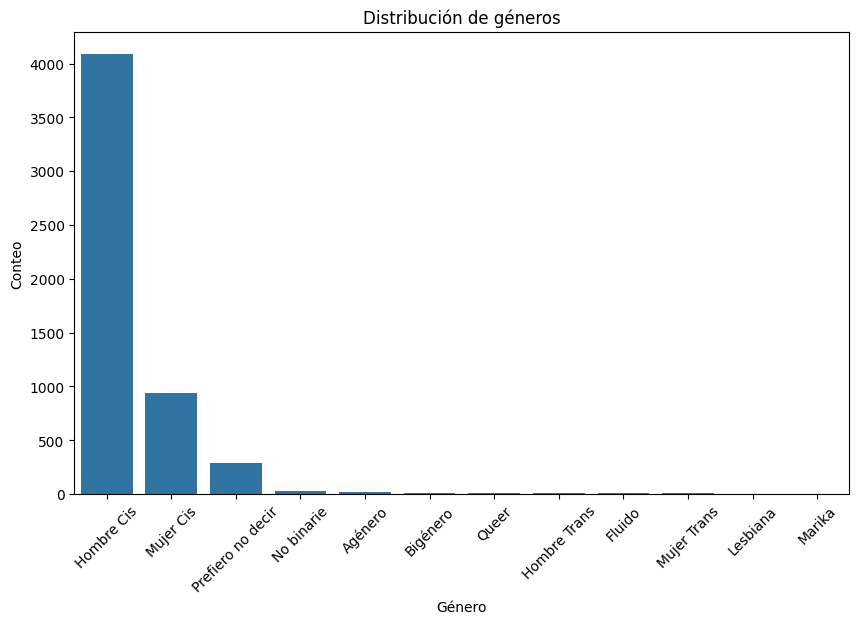

In [8]:

#Gráfico de barras para ver la relación entre los géneros.

plt.figure(figsize=(10, 6))  # Ajusta el tamaño de la figura
sns.barplot(x=gender_counts.index, y=gender_counts.values)

plt.xticks(rotation=45)  # Rota las etiquetas del eje X 45 grados
plt.xlabel('Género')
plt.ylabel('Conteo')
plt.title('Distribución de géneros')

plt.show()


#                     EDAD

También podemos explorar gráficamente el comportamiento de los datos de la variable edad, disponible en *tengo_edad.*

<Axes: xlabel='tengo_edad'>

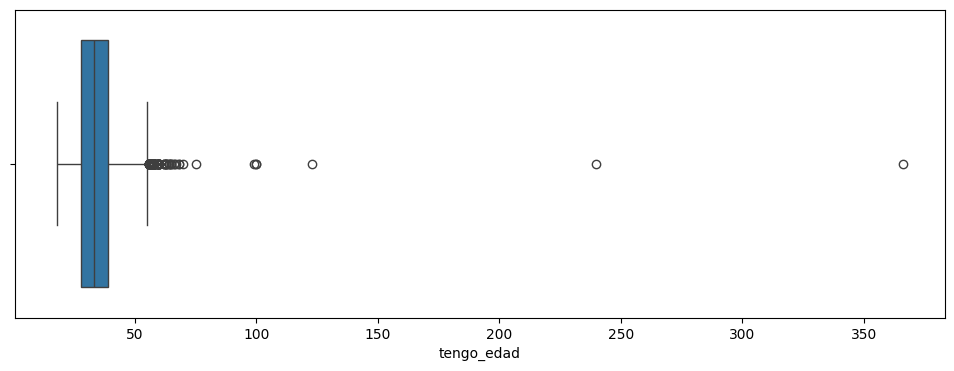

In [9]:
# Boxplot de la variable edad
plt.figure(figsize=(12, 4))
sns.boxplot(x=df.tengo_edad) # Ocurre algo raro con la edad: se ve una edad mayor a 350 años.

Como suele ocurrir al trabajar con cualquier conjunto de datos, puede haber errores en el registro. Por ejemplo, existe un caso de la muestra cuya edad reportada es superior a los 350 años. Naturalmente, esto corresponde a un error en la base de datos. Cuando identificamos casos como estos, que no caben dudas que son erróneos, es necesario removerlos para poder evitar que esos errores sesguen los análisis.

<Axes: xlabel='tengo_edad'>

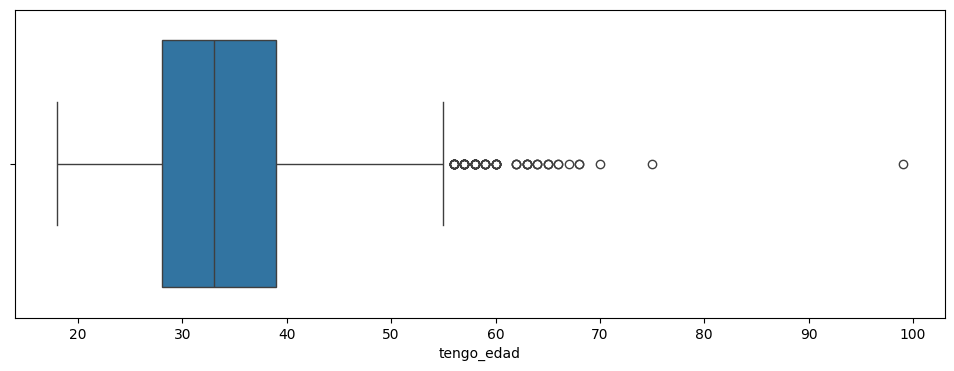

In [10]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df[df.tengo_edad < 100].tengo_edad) # Limitamos a registros de edades de menos de 100 años

Vemos que la edad se centra entre 28 y 38 años.

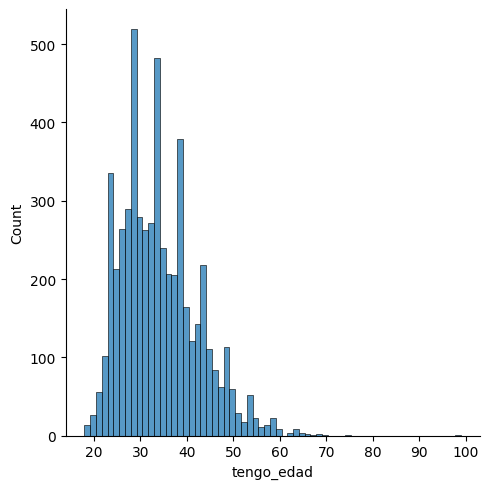

In [11]:
# Gráfico de distribución de la variable edad
sns.displot(df[df.tengo_edad < 100].tengo_edad)

En el siguiente gráfico vemos como se distribuye la edad según el género.

<Axes: xlabel='me_identifico_genero', ylabel='tengo_edad'>

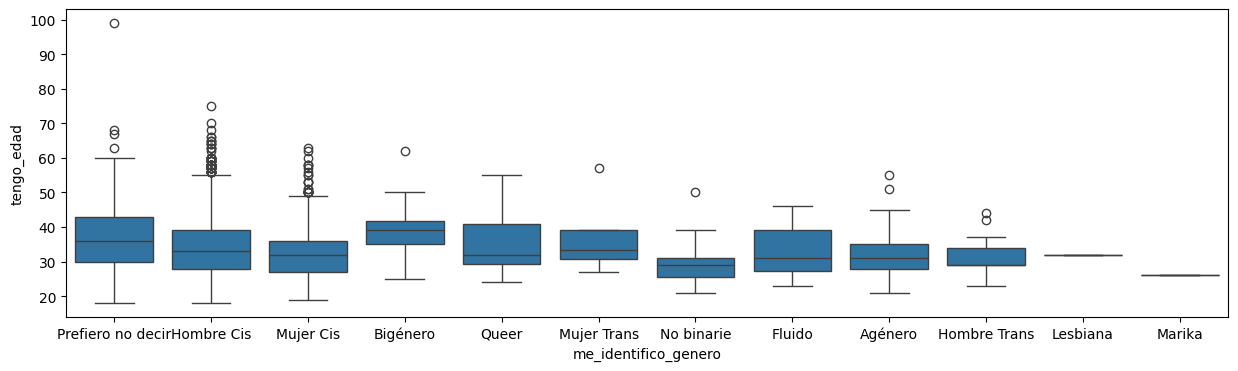

In [12]:
# Dataset filtrado preliminar
filtered_df = df[df['tengo_edad'] < 100]

plt.figure(figsize=(15, 4))
sns.boxplot(x='me_identifico_genero', y='tengo_edad', data=filtered_df)

#                          SALARIO



Pasamos a uno de los datos mas buscados (por no decir el más buscado). Veremos el análisis del *salario mensual bruto*

<Axes: xlabel='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'>

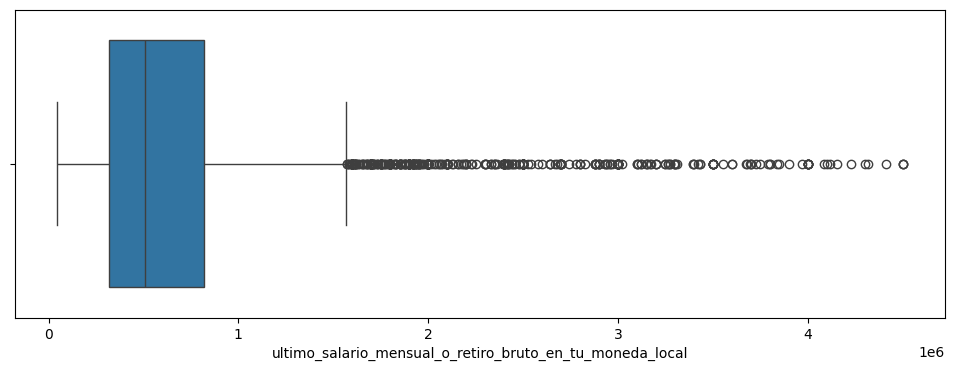

In [13]:
# Boxplot del salario
plt.figure(figsize=(12, 4))
sns.boxplot(x=df.ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local
)

<Axes: xlabel='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'>

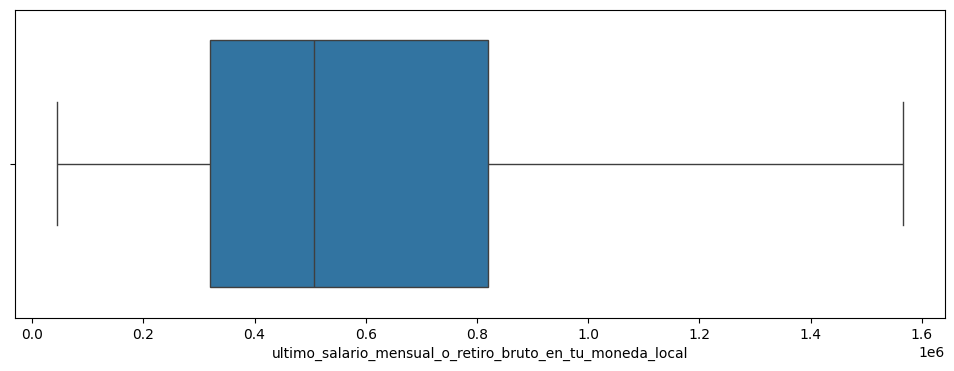

In [14]:
# Acá excluimos las observaciones que se marcaron como outliers en el gráfico anterior
plt.figure(figsize=(12, 4))
sns.boxplot(x=df.ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local, showfliers = False)

Veamos un histograma del salario mensual bruto y representemos la media y la mediana. En el segundo gráfico, tomamos los datos filtrados para salarios de menos de $820.000.

Es usual que la distribución del salario presente asimetría. Esto se observa, además, con la media y la mediana: como el salario es asimétrico a derecha, hay mucha concentración a izquierda, mostrando una "cola" de la distribución larga a derecha, pero con poco peso. Por eso, la media se ve traccionada a la derecha, superando a la mediana, que se mantiene a izquierda.

In [ ]:
# Hagamos dos gráficos en uno.
fig, axes = plt.subplots(nrows=2, figsize=(16, 8))

# Primer gráfico
sns.histplot(df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], bins=100, ax=axes[0], color='steelblue')
axes[0].axvline(df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].mean(), color='orangered', linestyle='--', label='Media')
axes[0].axvline(df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].median(), color='indigo',
            linestyle='-.', label='Mediana')

# Segundo gráfico, mismo histograma pero concentrando la visualización
# en la región de $0 a $820.000 (recordemos que el percentil 75 de estos datos
# ronda los $600000, es decir, en esta región estamos concentrando casi todos los datos)
filtered_df = df[df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'] < 820000]
sns.histplot(filtered_df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], ax=axes[1], color='steelblue')
axes[1].axvline(filtered_df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].mean(), color='orangered',
            linestyle='--', label='Media')
axes[1].axvline(filtered_df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].median(), color='indigo',
            linestyle='-.', label='Mediana')

axes[0].legend()

sns.despine()

# Salario bruto respecto al género y al nivel de estudios alcanzado

Primero veamos el salario bruto mensual por género.

In [ ]:
# Boxplots apilados del salario bruto mensual por género
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', y='me_identifico_genero')
plt.ticklabel_format(style='plain', axis='x')

Podemos observar que los Bigénero y Mujer Trans, tienen el salario bruto mensual mas alto. Esta tendencia tambien puede deberse a que, estos casos son un numero considerablemente menor respecto a Hombres cis y Mujeres cis, donde si se podria realizar una comparacion un poco mas equitativa con una tendencia a mejor pago por el lado de los Hombres.

Ahora veamoslo por nivel de estudios

In [ ]:
# Boxplots apilados del salario bruto mensual por nivel de estudios
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', y='maximo_nivel_de_estudios')
plt.ticklabel_format(style='plain', axis='x')

Veamos nuevamente el salario bruto mensual por género pero con otro tipo de gráfico
donde podemos observar mayor información (*los Boxenplot*)

In [ ]:
# Boxenplots apilados del salario bruto mensual por género
plt.figure(figsize=(12, 6))
sns.boxenplot(data=df, x='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', y='me_identifico_genero')
plt.ticklabel_format(style='plain', axis='x')

Salario bruto mensual por nivel de estudios

In [ ]:
# Boxenplots apilados del salario bruto mensual por nivel de estudios
plt.figure(figsize=(12, 6))
sns.boxenplot(data=df, x='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', y='maximo_nivel_de_estudios')
plt.ticklabel_format(style='plain', axis='x')

REDUCIMOS EL NRO DE ENCUESTADOS AL 98% CON UN MARGEN DE EDAD DE HASTA 100 AÑOS

También podemos tomar la decisión de eliminar valores extremos, que por alguna razón consideremos como atípicos y que, en caso de dejarlos, obturarían mucho el cálculo de promedios, que es una de las herramientas estadísticas más frecuentemente usada.

Algo así hicimos con la variable de la edad, pero en ese caso, era evidente que se trataba de un registro erróneo: ningún participante puede tener 350 años. Sin embargo, afirmar algo así en el caso de salarios es más difícil: en esta muestra, hay registros de usuarios que ganan más de 4.000.000 de pesos; una cifra, poco probable pero tampoco descabellado. No podemos afirmar que casos como esos correspondan a errores de registro.

No obstante, siendo casos realmente minoritarios, podemos decidir excluirlos en aras de no sesgar estadísticos sensibles a estos valores extremos como la media o el desvío estándar.

Por ejemplo, podemos elegir quedarnos con el 98% de salarios más bajos, eliminando el 2% superior. Podemos calcular todos los percentiles para decidir cuál sería el más apropiado.

In [ ]:
# Algunos percentiles de interés
df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].quantile([.95, .98, .99, .998])

Así vemos que el 98% de los encuestados tienen un salario bruto de $2880000 o menos.

In [ ]:
plt.figure(figsize=(12, 4))
max_limit = df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].quantile(.98) # Definimos este límite a ojo
sns.boxenplot(x=df[df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'] < max_limit]['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'])
# Nos quedamos con los datos reducidos a ese nuevo conjunto

Para lo que sigue, nos quedaremos con el dataset reducido a este conjunto.

In [ ]:
# Histograma, boxplot y boxenplot de los nuevos datos
fig, axes = plt.subplots(figsize=(12, 12), nrows=3)
max_limit = df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].quantile(.98)
data = df[df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'] < max_limit]['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local']
sns.histplot(x=data, ax=axes[0])
sns.boxplot(x=data, ax=axes[1])
sns.boxenplot(x=data, ax=axes[2])

Creamos el dataset reducido df_red quedándonos con 5306 registros, que corresponden a los encuestados que concentran el 98% de los salarios brutos mensuales más bajos. Es decir, excluimos al 2% de mayores salarios de la base de datos original y, también a los de la edad superior a 100 años que observamos antes.

In [ ]:
df_red = df[df['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'] < max_limit]
df_red = df_red[df_red['tengo_edad'] < 100]
df_red

In [ ]:
df_red.describe()

*Volvemos* a mirar la distribución por género y por nivel de estudios alcanzado o en curso.

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxenplot(data=df_red, x='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', y='me_identifico_genero')
plt.ticklabel_format(style='plain', axis='x')

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxenplot(data=df_red, x='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', y='maximo_nivel_de_estudios')
plt.ticklabel_format(style='plain', axis='x')

Una tabla de contingencia permite ver, de forma desagregada, la cantidad de casos para el nivel de estudio según el género. Un mapa de calor puede ser útil para identificar visualmente la magnitud de la concentración de casos en cada celda.

In [ ]:
# Tabla de contingencia para ver nivel de estudios según género
pd.crosstab(df_red.me_identifico_genero, df_red.maximo_nivel_de_estudios)#, normalize=True)

In [ ]:
# Mapa de calor de la tabla anterior
# Ordenamos los niveles para mejor lectura
sorted_studies_levels = ['Secundario', 'Terciario', 'Universitario', 'Posgrado/Especialización', 'Doctorado', 'Posdoctorado', 'Maestría' ]
fig = plt.figure(figsize=(10,6))
exp = pd.crosstab(df_red.me_identifico_genero,
                  df_red.maximo_nivel_de_estudios)[sorted_studies_levels]
sns.heatmap(exp, annot=True, fmt='g')

# AHORA VEREMOS DATOS RELACIONADOS A LOS AÑOS DE EXPERIENCIA

Otra variable de interés en relación con el salario puede ser la cantidad de años de experiencia, dado que este conjunto de datos aun no incluía información sobre el seniority. Esa variable está disponible en *anos_de_experiencia*, y podemos hacer un gráfico como el que sigue.

In [ ]:
plt.figure(figsize=(24, 6))
sns.barplot(x='anos_de_experiencia', y='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', data=df_red)

También podemos relacionar esa variable con la de la edad de los individuos, viendo una tendencia creciente razonable. Este gráfico también puede ayudar a encontrar datos mal registrados: por ejemplo, una persona de menos de 30 años no debería tener mucho más de 10 años de experiencia.

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='anos_de_experiencia', y='tengo_edad', data=df_red)

In [ ]:
df_red['dif_age_yearsexp'] = df_red['tengo_edad']-df_red['anos_de_experiencia']
plt.figure(figsize=(10, 6))
sns.boxplot(x='dif_age_yearsexp', data=df_red)

Podemos excluir, también, estos casos sospechosos suponiendo que la diferencia entre la edad y los años de experiencia debería ser, como mínimo, de 16 años.

In [ ]:
df_red = df_red[df_red['dif_age_yearsexp'] > 15]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='anos_de_experiencia', y='tengo_edad', data=df_red)

# Relacionamos los años de experiencia con el salario, así como la edad con el salario.

In [ ]:
# Gráfico de dispersión de años de experiencia y salario
plt.figure(figsize=(10, 6))
sns.scatterplot(x='anos_de_experiencia', y='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', data=df_red)

In [ ]:
# Distribución conjunta de salario y edad
sns.jointplot(data=df_red, x='tengo_edad', y='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', kind='hex', height=6)
# Para remover la notación científica
plt.ticklabel_format(style='plain', axis='y')

La satisfacción con el salario, disponible en *que_tan_conforme_estas_con_tus_ingresos_laborales* puede verse cruzada por el salario y por el género. Como es esperable, la mayor satisfacción se tiene para salarios altos, independientemente del género.



In [ ]:
plt.figure(figsize=(12, 6))
sns.catplot(data=df_red, y='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', x='que_tan_conforme_estas_con_tus_ingresos_laborales', height=4, aspect=2, kind= 'boxen', hue='me_identifico_genero')

# **FORMULACION DE HIPOTESIS**

Luego de la exploración inicial, y del posible filtro que se haya hecho de los datos, es posible elaborar algunas conjeturas o hipótesis iniciales. Por ejemplo, hemos visto que el salario bruto mensual se ve muy influenciado por el género y por el nivel de estudios alcanzado o en curso.

En primera instancia hicimos un gráfico comprando 'Hombre Cis' y 'Mujer Cis'. El gráfico que sigue es una **estimación de la densidad** del salario bruto por género, que en el caso masculino exime una mayor asimetría que en el femenino, siendo este último, además, más corrido a izquierda.

In [ ]:
df_H = df_red[df_red['me_identifico_genero']=='Hombre Cis']
df_M = df_red[df_red['me_identifico_genero']=='Mujer Cis']

plt.figure(figsize=(10, 6))
sns.kdeplot(df_H['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='steelblue', label='Hombres Cis', fill=True)
sns.kdeplot(df_M['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='orange', label='Mujeres Cis', fill=True)

plt.title('Distribución de Salario Mensual Bruto por Género (Gráfico de Densidad)')
plt.xlabel('Salario Mensual Bruto')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Hicimos un segundo gráfico con los géneros menos elegidos por los encuestados para un mejor lectura. Los géneros 'Lesbiana' y 'Marika' no fueron tenidos en cuenta al haber un solo dato de cada uno.

Hipótesis: Existen diferencias significativas en la distribución del salario mensual bruto entre los distintos géneros, lo que sugiere que el género puede influir en los niveles de remuneración en el mercado laboral.

Densidad y Pico de Distribución: La mayoría de las distribuciones de los salarios mensuales brutos parecen tener un pico alrededor del mismo rango, pero con diferentes niveles de densidad.

Hombre Trans y Mujer Trans: Estas categorías parecen tener distribuciones más dispersas, indicando una mayor variabilidad en los salarios.
No binarie, Agénero, Fluido: Estas categorías muestran picos de densidad más bajos, sugiriendo que hay menos personas en estos grupos en comparación con los grupos de Hombre Trans y Mujer Trans.

Colas de las Distribuciones: Las distribuciones tienen colas que se extienden a valores de salario más altos.

Mujer Trans: Parece tener una cola más larga, indicando que aunque la mayoría de los salarios están concentrados en un rango más bajo, hay algunos individuos que reciben salarios significativamente más altos.
Hombre Trans y No binarie: También tienen colas largas, pero no tan pronunciadas como Mujer Trans.

Hay una considerable superposición entre las distribuciones de diferentes géneros, lo que sugiere que aunque hay diferencias, hay también similitudes en los rangos salariales.

Esta superposición indica que mientras el género puede influir en el salario, no es el único factor determinante.

In [ ]:

# Crear DataFrames filtrados por género
df_PND = df[df['me_identifico_genero']=='Prefiero no decir']
df_A = df[df['me_identifico_genero']=='Agénero']
df_NB = df[df['me_identifico_genero']=='No binarie']
df_HT = df[df['me_identifico_genero']=='Hombre Trans']
df_MT = df[df['me_identifico_genero']=='Mujer Trans']
df_F = df[df['me_identifico_genero']=='Fluido']
df_B = df[df['me_identifico_genero']=='Bigenero']
df_Q = df[df['me_identifico_genero']=='Queer']

# Crear el gráfico KDE
plt.figure(figsize=(12, 8))

sns.kdeplot(df_PND['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='darkgreen', label='Prefiero no decir', fill=True)
sns.kdeplot(df_A['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='lawngreen', label='Agénero', fill=True)
sns.kdeplot(df_NB['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='blueviolet', label='No binarie', fill=True)
sns.kdeplot(df_HT['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='magenta', label='Hombre Trans', fill=True)
sns.kdeplot(df_MT['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='aqua', label='Mujer Trans', fill=True)
sns.kdeplot(df_F['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='pink', label='Fluido', fill=True)
sns.kdeplot(df_B['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='blue', label='Bigenero', fill=True)
sns.kdeplot(df_Q['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='black', label='Queer', fill=True)

# Configurar el título y etiquetas del gráfico
plt.title('Distribución de Salario Mensual Bruto por Género (Gráfico de Densidad)')
plt.xlabel('Salario Mensual Bruto')
plt.ylabel('Densidad')
plt.legend()
plt.show()


#Distribución  del salario por nivel educativo

In [ ]:
plt.figure(figsize=(10, 6))

# Filtra los datos por nivel educativo
education_levels = df_red['maximo_nivel_de_estudios'].unique()

for level in education_levels:
    df_subset = df_red[df_red['maximo_nivel_de_estudios'] == level]
    sns.kdeplot(df_subset['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], label=level, fill=True)

plt.title('Distribución de Salario Mensual Bruto por Nivel Educativo (Gráfico de Densidad)')
plt.xlabel('Salario Mensual Bruto')
plt.ylabel('Densidad')
plt.legend(title='Nivel Educativo')
plt.show()

Sabemos que las muestras exhiben una variabilidad inherente al proceso de muestre. Sin embargo, podríamos preguntarnos si estas diferencias son razonablemente atribuibles al proceso de muestreo. Más precisamente, como sabemos que la media muestral tiene distribución aproximadamente normal cuando las muestras son "grandes" y conocemos la regla empírica 68-95-99, podríamos elaborar un primer razonamiento inferencial.

#### Intervalo de confianza para la media

Ya vimos que el **Teorema central del límite** (TCL) establece que, bajo hipótesis no muy rígidas sobre variables aleatorias $X_i$ (que sean independientes, que todas tengan la misma distribución y con esperanza $E(X)=\mu$ y varianza $V(X)=\sigma^2$ finitas), la distribución límite de la variable

$$
Z_n=\frac{\overline{X}_n-\mu}{\sigma/\sqrt{n}}
$$

es la distribución $N(0,1)$.

Es decir, cuando $n\longrightarrow \infty$,

$$
\frac{\overline{X}_n-\mu}{\sigma/\sqrt{n}} \stackrel{\mathcal{D}}{\longrightarrow} N(0,1).
$$

Naturalmente, el $n$ de cualquier experimento o simulación que hagamos nunca será infinito, sin embargo, el resultado anterior suele ser "bueno" aún para $n$ finitos y no muy grandes. Es decir, para un $n$ fijo y suficientemente grande,

$$\frac{\overline{X}_n-\mu}{\sigma/\sqrt{n}} \approx N(0,1),$$

donde el símbolo "$\approx$" denota que la distribución NO es exacta, sino aproximada.

Y, en esa línea, podemos pensar que para un $n$ fijo y suficientemente grande,

$$\overline{X}_n \approx N(\mu,\sigma^2/n).$$

Hilando más fino, con la distribución aproximada de $\overline{X}_n$ es posible construir intervalos de confianza para $\mu$. **¿Qué es un intervalo de confianza?**

Se llama intervalo de confianza a un par de números entre los cuales se estima que estará cierto valor desconocido respecto de un parámetro poblacional con un determinado nivel de confianza. Formalmente, estos números determinan un intervalo, que se calcula a partir de datos de una muestra, y el valor desconocido es un parámetro poblacional. El nivel de confianza representa el porcentaje de intervalos que tomados de 100 muestras independientes distintas contienen en realidad el valor desconocido.

Por ejemplo, dada una muestra de salarios, podríamos estimar que el verdadero salario bruto promedio $\mu$ de una población se encuentra entre los \$694.221,28 y los \$ 710.404,59 con un nivel de confianza del 95\%. Es decir, si repitiéramos esta encuesta 100 veces, en 95 de esas 100 veces esperaríamos estar "capturando" al verdadero $\mu$ de la población en este intervalo.

Un intervalo de nivel $1-\alpha$ para este problema se construye así:

$$\left[\overline{X}_n-z_{\alpha/2}\frac{S}{\sqrt{n}}; \overline{X}_n+z_{\alpha/2}\frac{S}{\sqrt{n}}\right]$$

donde $S$ es la desviación muestral y es la que estima a la verdadera desviación $\sigma$, que en este caso no es conocido; y $z_{\alpha/2}$ es el percentil que deja área $\alpha/2$ a derecha de una distribución normal estándar.

Por ejemplo, un intervalo de confianza de nivel $0.95$ exige un $\alpha$ de 0.05 que es el que determina el percentil $z_{0.05/2}=z_{0.025}$ y que se puede calcular como se muestra debajo.

In [ ]:
z = stats.norm.ppf((1 + 0.95) / 2)
z

Es decir, un intervalo de nivel $0.95$ para la media de salario bruto en este este problema sería

$$\left[\overline{X}_n-1.96\frac{S}{\sqrt{n}}; \overline{X}_n+1.96\frac{S}{\sqrt{n}}\right].$$

Podemos calcular un intervalo de confianza para la media de salario bruto como sigue.

In [ ]:
# Calcula la media y el error estándar estimado (S sobre sqrt n)
mean = df_red['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].mean()
std_error = df_red['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].std() / np.sqrt(len(df_red['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local']))

# Calcula el valor crítico de la distribución normal estándar para el nivel de confianza
conf_level = 0.95
z = stats.norm.ppf((1 + conf_level) / 2)

# Calcula el intervalo de confianza
lower_bound = mean - z * std_error
upper_bound = mean + z * std_error

print(lower_bound)
print(upper_bound)

Con los datos de salarios en el dataset que hemos reducido, entonces, podríamos concluir que un intervalo de nivel $0.95$ para la media de salario bruto es aproximadamente

$$\left[625.001; 650.112\right].$$

Pero, cuidado, ¡este salario medio supone una única población! No está considerando que pudiera haber diferencias por género, por nivel educativo o por cualquier otra consideración.


**¿Para qué podríamos usar esto?**

Podríamos, por ejemplo, ver cómo son los intervalos de confianza para el salario medio de las poblaciones por género o por nivel educativo y usar esos resultados para ver si los intervalos se solapan o no. Si se solapan, sería difícil suponer que las medias verdaderas son distintas. Sin embargo, si no se solaparan, todo parecería indicar que no es razonable suponer que son iguales (pues, de serlo, uno esperaría obtener intervalos "similares" en ambas poblaciones).

NOTA: esto es apenas un "coqueteo" con la estadística inferencial. En efecto, existen métodos mejores y más sofisticados que este simple esbozo para someter a prueba hipótesis estadísticas.

#### Sueldo medio según _género_

Vamos a construir intervalos de confianza para las medias por género. Es decir, suponemos que hay dos medias
$$\mu_H, \quad \mu_M$$
donde la H y la M corresponden a los géneros "Hombre" y "Mujer", respectivamente. Descartamos el caso de "Otros" por tratarse de una muestra muy pequeña.

Si las medias fueran iguales
$$\mu_H = \mu_M$$
uno esperaría que los intervalos que se obtengan a partir de ambas muestras sean "parecidos".

Hagamos las cuentas que hicimos antes, pero para estas submuestras de hombres y mujeres.

In [ ]:
# Filtramos los datos para eliminar valores nulos y descarta el caso de "otros"
filtered_df = df_red[df_red['me_identifico_genero'].isin(['Hombre Cis', 'Mujer Cis'])]
filtered_df = filtered_df.dropna(subset=['me_identifico_genero', 'ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'])

# Creamos una lista para almacenar los resultados de los intervalos
results = []

# Definimos el nivel de confianza (por ejemplo, 95%)
conf_level = 0.95

# Iteramos a través de los géneros únicos y calculamos el intervalo de confianza
for gender in filtered_df['me_identifico_genero'].unique():
    subset = filtered_df[filtered_df['me_identifico_genero'] == gender]
    salary_data = subset['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local']

    # Calculamos la media y el error estándar estimado
    mean = salary_data.mean()
    std_error = salary_data.std() / np.sqrt(len(salary_data))

    # Calculamos el valor crítico de la distribución normal estándar para el nivel de confianza
    z = stats.norm.ppf((1 + conf_level) / 2)

    # Calculamos el intervalo de confianza
    lower_bound = mean - z * std_error
    upper_bound = mean + z * std_error

    results.append({'Género': gender, 'Media': mean, 'Intervalo de Confianza': (lower_bound, upper_bound)})

# Convertimos la lista de resultados en un DataFrame
result_df = pd.DataFrame(results)

# Imprimimos el DataFrame de resultados
print(result_df)

¿Qué observamos?

*  Mujeres: La media del salario bruto para las mujeres es de aproximadamente \$532.954  con un intervalo de confianza entre \$507.514 y \$ 558.393. Esto indica que, con un nivel de confianza del 95\%, se espera que la verdadera media del salario bruto de las mujeres esté dentro de ese rango.

*  Hombres: La media del salario bruto para los hombres es de aproximadamente \$661.547 con un intervalo de confianza entre \$646.793 y \$676.302. Esto sugiere que la verdadera media del salario bruto de los hombres se encuentra dentro de ese intervalo con un 95\% de confianza.

**En base a estos resultados, podemos concluir que, en promedio, los hombres tienen un salario bruto mayor que las mujeres, ya que el intervalo de confianza de la media para los hombres no se superpone con el de las mujeres.**


Podríamos poner un nivel de confianza mayor, para aumentar la sensación de certeza. Por ejemplo: 99\%.

In [ ]:
# Creamos una lista para almacenar los resultados de los intervalos
results = []

# Definimos el nivel de confianza (por ejemplo, 95%)
conf_level = 0.99

# Iteramos a través de los géneros únicos y calculamos el intervalo de confianza
for gender in filtered_df['me_identifico_genero'].unique():
    subset = filtered_df[filtered_df['me_identifico_genero'] == gender]
    salary_data = subset['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local']

    # Calculamos la media y el error estándar estimado
    mean = salary_data.mean()
    std_error = salary_data.std() / np.sqrt(len(salary_data))

    # Calculamos el valor crítico de la distribución normal estándar para el nivel de confianza
    z = stats.norm.ppf((1 + conf_level) / 2)

    # Calculamos el intervalo de confianza
    lower_bound = mean - z * std_error
    upper_bound = mean + z * std_error

    results.append({'Género': gender, 'Media': mean, 'Intervalo de Confianza': (lower_bound, upper_bound)})

# Convertimos la lista de resultados en un DataFrame
result_df = pd.DataFrame(results)

# Imprimimos el DataFrame de resultados
result_df

Y si bien los intervalos obtenidos son más "largos", pues aumentamos la confianza con la que afirmamos esto, aun así siguien estando separados, no se solapan. Es decir, la conclusión no cambia.

#### Sueldo medio según _genero_ para _nivel universitario completo_



Como todo en estadística, ninguna conclusión es una verdad absoluta. Simplemente se trata de una conclusión a la que se llega con un procedimiento válido desde la teoría, y que surge a parti de los datos recabados, que tampoco constituye un muestreo estadístico que garantice independencia, representatividad, etcétera.

No obstante, a partir de los datos hay evidencia para suponer que el salario bruto mensual PROMEDIO de las mujeres es inferior al salario bruto mensual PROMEDIO de los hombres.

Ahora bien, uno podría pensar, por ejemplo, que esa diferencia observada no se debe al género, sino a alguna otra variable latente que pudiera haber. Solo por mencionar una, quizás ocurre que la muestra de los hombres tiene casos de encuestados con mayor formación y, por ende, con salarios mejores.

Podríamos, entonces, replicar el análisis anterior pero controlando por el nivel universitario: por ejemplo, quedándonos únicamente con los datos de hombres y mujeres con nivel universitario completo.

In [ ]:
# Filtramos los datos para eliminar valores nulos y para incluir solo hombres y mujeres universitarios con estudios completos
filtered_df = df_red.dropna(subset=['me_identifico_genero', 'ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', 'maximo_nivel_de_estudios', 'estado'])
filtered_df = filtered_df[(filtered_df['maximo_nivel_de_estudios'] == 'Universitario') &
                          (filtered_df['estado'] == 'Completo') &
                          (filtered_df['me_identifico_genero'].isin(['Hombre Cis', 'Mujer Cis']))]

In [ ]:
# Boxplot del salario mensual bruto por género para universitario completo
plt.figure(figsize=(12, 6))
sns.boxenplot(data=filtered_df, x='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', y='me_identifico_genero')
plt.ticklabel_format(style='plain', axis='x')

In [ ]:
# Densidad del salario mensual bruto por género para universitario completo
plt.figure(figsize=(10, 6))
sns.kdeplot(filtered_df[filtered_df['me_identifico_genero'] == 'Hombre Cis']['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='steelblue', label='Hombres', fill=True)
sns.kdeplot(filtered_df[filtered_df['me_identifico_genero'] == 'Mujer Cis']['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='orange', label='Mujeres', fill=True)
plt.legend(title='Género')
plt.show()

In [ ]:
# Repetimos el cálculo del IC
results = []

conf_level = 0.95

for gender in ['Hombre Cis', 'Mujer Cis']:
    subset = filtered_df[filtered_df['me_identifico_genero'] == gender]
    salary_data = subset['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local']

    # Calcula la media y el error estándar estimado
    mean = salary_data.mean()
    std_error = salary_data.std() / np.sqrt(len(salary_data))

    # Calcula el valor crítico de la distribución normal estándar para el nivel de confianza
    z = stats.norm.ppf((1 + conf_level) / 2)

    # Calcula el intervalo de confianza
    lower_bound = mean - z * std_error
    upper_bound = mean + z * std_error

    results.append({'Género': gender, 'Media': mean, 'Intervalo de Confianza': (lower_bound, upper_bound)})

result_df = pd.DataFrame(results)
result_df

Nuevamente, los intervalos no se solapan y la conclusión no cambia. Es decir:

**En base a estos resultados, podemos concluir que, en promedio y a nivel 95%, los hombres con nivel universitario completo tienen un salario mensual bruto mayor que las mujeres con nivel universitario completo.**


#### Sueldo medio según _genero_ para _nivel universitario completo_ y menos de 10 años de experiencia

Podríamos, por último, replicar el análisis anterior pero controlando no solo por el nivel universitario sino por los años de experiencia: por ejemplo, quedándonos únicamente con los datos de hombres y mujeres con nivel universitario completo y con menos de 10 años de experiencia.

In [ ]:
# Filtramos los datos para eliminar valores nulos y para incluir solo hombres y mujeres universitarios con estudios completos
filtered_df = df_red.dropna(subset=['me_identifico_genero', 'ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', 'maximo_nivel_de_estudios', 'estado'])
filtered_df = filtered_df[(filtered_df['maximo_nivel_de_estudios'] == 'Universitario') &
                          (filtered_df['estado'] == 'Completo') &
                          (filtered_df['anos_de_experiencia'] < 10) &
                          (filtered_df['me_identifico_genero'].isin(['Hombre Cis', 'Mujer Cis']))]

Es importante verificar que sigamos teniendo suficientes datos como para que el intervalo que se basa en la aproximación normal siga siendo razonable.

In [ ]:
len(filtered_df[filtered_df['me_identifico_genero']=='Mujer Cis'])

In [ ]:
len(filtered_df[filtered_df['me_identifico_genero']=='Hombre Cis'])

In [ ]:
# Repetimos el cálculo del IC
results = []

conf_level = 0.95

for gender in ['Hombre Cis', 'Mujer Cis']:
    subset = filtered_df[filtered_df['me_identifico_genero'] == gender]
    salary_data = subset['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local']

    # Calcula la media y el error estándar estimado
    mean = salary_data.mean()
    std_error = salary_data.std() / np.sqrt(len(salary_data))

    # Calcula el valor crítico de la distribución normal estándar para el nivel de confianza
    z = stats.norm.ppf((1 + conf_level) / 2)

    # Calcula el intervalo de confianza
    lower_bound = mean - z * std_error
    upper_bound = mean + z * std_error

    results.append({'Género': gender, 'Media': mean, 'Intervalo de Confianza': (lower_bound, upper_bound)})

result_df = pd.DataFrame(results)
result_df

Nuevamente, los intervalos no se solapan y la conclusión no cambia. Es decir:

**En base a estos resultados, podemos concluir que, en promedio y a nivel 95%, los hombres con nivel universitario completo y menos de 10 años de experiencia tienen un salario mensual bruto mayor que las mujeres con nivel universitario completo y menos de 10 años de experiencia.**

#Conjetura sometida a prueba:  Desarrollador Cobol vs Otros Desarrolladores

## Introducción

Analizaremos los salarios de los desarrolladores que trabajan con COBOL y los compararemos con los de desarrolladores de otros lenguajes de programación. Planteamos como hipótesis que un programador de COBOL gana más en promedio que cualquier otro programador debido a la rareza y demanda específica de sus habilidades. También tomamos como hipotesis que en promedio la edad de un programador Cobol es mayor a un desarrollador de otro lenguaje. Lo mismo planteamos como hipótesis que en general un programador Cobol va tener más años de experiecia que un programador de otro lenguaje.

#Análisis de Datos
Exploración descriptiva inicial

In [ ]:
url = 'https://raw.githubusercontent.com/damianclausi/Trabajo-Practico-3-EyPDS---CSV/main/Sysarmy-2023-2.csv'
data = pd.read_csv(url)

# Filtrar los datos para obtener solo los desarrolladores
developers_data = data[data['trabajo_de'].str.contains('Developer', case=False, na=False)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Contar la cantidad de desarrolladores COBOL y otros
developers_data['es_cobol'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)
developer_counts = developers_data['es_cobol'].value_counts().rename(index={True: 'COBOL', False: 'Otros'})

# Crear un DataFrame para mostrar la cantidad de desarrolladores
developer_counts_df = developer_counts.reset_index()
developer_counts_df.columns = ['Tipo de Desarrollador', 'Cantidad de Encuestados']

# Mostrar el DataFrame
print(developer_counts_df)

In [ ]:

# Filtrar los datos para obtener solo los desarrolladores
developers_data = data[data['trabajo_de'].str.contains('Developer', case=False, na=False)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Contar la cantidad de desarrolladores COBOL y otros
developers_data['es_cobol'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)
developer_counts = developers_data['es_cobol'].value_counts().rename(index={True: 'COBOL', False: 'Otros'})

# Crear un DataFrame para mostrar la cantidad de desarrolladores
developer_counts_df = developer_counts.reset_index()
developer_counts_df.columns = ['Tipo de Desarrollador', 'Cantidad de Encuestados']

# Mostrar el DataFrame
print(developer_counts_df)

# Gráfico de barras para ver la relación entre desarrolladores COBOL y otros
plt.figure(figsize=(8, 6))
barplot = sns.barplot(x='Tipo de Desarrollador', y='Cantidad de Encuestados', hue='Tipo de Desarrollador', data=developer_counts_df, palette={'COBOL': 'red', 'Otros': 'blue'})
plt.title('Cantidad de Desarrolladores COBOL y Otros')
plt.xlabel('Tipo de Desarrollador')
plt.ylabel('Cantidad de Encuestados')
plt.xticks(rotation=0)
plt.legend([], [], frameon=False)

# Agregar números en las barras
for index, value in enumerate(developer_counts_df['Cantidad de Encuestados']):
    barplot.text(index, value + 50, f'{value}', color='black', ha="center")

plt.show()

Exploramos graficamente variable 'tengo_edad', comparando la edad de los progamadores Cobol y demás lenguajes.

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores
developers_data = data[data['trabajo_de'].str.contains('Developer', case=False, na=False)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Añadir una columna para identificar desarrolladores COBOL
developers_data['es_cobol'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)
developers_data['Tipo de Desarrollador'] = developers_data['es_cobol'].map({True: 'COBOL', False: 'Otros'})


# Crear el boxplot para comparar la edad de desarrolladores COBOL y otros
plt.figure(figsize=(12, 6))
sns.boxplot(x='Tipo de Desarrollador', y='tengo_edad', data=developers_data)
plt.title('Distribución de la Edad de Desarrolladores COBOL y Otros')
plt.xlabel('Tipo de Desarrollador')
plt.ylabel('Edad')
plt.show()

Arriba de 90 años clarmente son datos erroneos y los vamos a limitar.

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores
developers_data = data[data['trabajo_de'].str.contains('Developer', case=False, na=False)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Añadir una columna para identificar desarrolladores COBOL
developers_data['es_cobol'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)
developers_data['Tipo de Desarrollador'] = developers_data['es_cobol'].map({True: 'COBOL', False: 'Otros'})

# Limpiar los datos de edades para eliminar valores atípicos extremos (edad mayor a 90 años)
developers_data = developers_data[developers_data['tengo_edad'] <= 90]

# Crear el boxplot para comparar la edad de desarrolladores COBOL y otros
plt.figure(figsize=(12, 6))
sns.boxplot(x='Tipo de Desarrollador', y='tengo_edad', data=developers_data)
plt.title('Distribución de la Edad de Desarrolladores COBOL y Otros')
plt.xlabel('Tipo de Desarrollador')
plt.ylabel('Edad')

A continuación obtenemos la distribución de frecuancias de las edades de los desarrolladores de COBOL.

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores
developers_data = data[data['trabajo_de'].str.contains('Developer', case=False, na=False)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Filtrar los datos para obtener solo los desarrolladores COBOL
cobol_developers = developers_data[developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Limpiar los datos de edades para eliminar valores atípicos extremos (edad mayor a 90 años)
cobol_developers = cobol_developers[cobol_developers['tengo_edad'] < 90]

# Crear el gráfico de distribución para la edad de programadores COBOL
plt.figure(figsize=(10, 6))
sns.histplot(cobol_developers['tengo_edad'], kde=True, color='red', bins=10)
plt.title('Distribución de la Edad de Desarrolladores COBOL')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

A continuación obtenemos la distribución de las edades de los desarrolladores que no usan COBOL.

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores
developers_data = data[data['trabajo_de'].str.contains('Developer', case=False, na=False)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Filtrar los datos para obtener solo los desarrolladores que no usan COBOL
other_developers = developers_data[~developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Limpiar los datos de edades para eliminar valores atípicos extremos (edad mayor a 90 años)
other_developers = other_developers[other_developers['tengo_edad'] < 90]

# Crear el gráfico de distribución para la edad de otros desarrolladores
plt.figure(figsize=(10, 6))
sns.histplot(other_developers['tengo_edad'], kde=True, color='blue', bins=10)
plt.title('Distribución de la Edad de Desarrolladores (Excepto COBOL)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

Filtramos como se distribuye la edad según el lenguaje de programación.

In [ ]:


# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Explode los lenguajes de programación en filas separadas
developers_data = developers_data.assign(lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual=developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.split(',')).explode('lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual')
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip()

# Contar los lenguajes de programación
language_counts = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].value_counts()

# Asegurarnos de que COBOL esté incluido en los 10 lenguajes más comunes
top_languages = language_counts.head(10).index.tolist()
if 'cobol' not in top_languages:
    top_languages[-1] = 'cobol'

# Filtrar los datos para los lenguajes principales incluyendo COBOL
filtered_developers_data = developers_data[developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].isin(top_languages)]

# Crear el boxplot para comparar la edad de los desarrolladores por lenguaje de programación
plt.figure(figsize=(15, 8))
sns.boxplot(x='lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual', y='tengo_edad', data=filtered_developers_data, hue='lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual', dodge=False, palette='Set3')
plt.title('Distribución de la Edad de Desarrolladores por Lenguaje de Programación')
plt.xlabel('Lenguaje de Programación')
plt.ylabel('Edad')
plt.xticks(rotation=45)
plt.legend([], [], frameon=False)
plt.show()


Claramente se ve como el rango de edad de un desarrollador Cobol es mayor al de cualquier otro lenguaje.

Ahora vamos a analizar el salario mensual bruto de un programador Cobol vs Otros programadores.

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Crear una columna para identificar desarrolladores COBOL
developers_data['es_cobol'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)
developers_data['Lenguaje de Programación'] = developers_data['es_cobol'].map({True: 'COBOL', False: 'Otros'})

# Filtrar los datos para asegurarse de que solo incluimos los desarrolladores relevantes
filtered_developers_data = developers_data[developers_data['Lenguaje de Programación'].isin(['COBOL', 'Otros'])]

# Crear el boxplot para comparar el salario de desarrolladores COBOL y otros
plt.figure(figsize=(12, 6))
sns.boxplot(x='Lenguaje de Programación', y='ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local', data=filtered_developers_data)
plt.title('Distribución del Salario de Desarrolladores COBOL y Otros')
plt.xlabel('Lenguaje de Programación')
plt.ylabel('Salario Mensual Neto en Moneda Local')
plt.show()

Se elimina los outliers tanto en la edad como en el salario.


In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Crear una columna para identificar desarrolladores COBOL
developers_data['es_cobol'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)
developers_data['Lenguaje de Programación'] = developers_data['es_cobol'].map({True: 'COBOL', False: 'Otros'})

# Filtrar los datos para asegurarse de que solo incluimos los desarrolladores relevantes
filtered_developers_data = developers_data[developers_data['Lenguaje de Programación'].isin(['COBOL', 'Otros'])]

# Crear el boxplot para comparar el salario de desarrolladores COBOL y otros, excluyendo outliers visualmente
plt.figure(figsize=(12, 6))
sns.boxplot(x='Lenguaje de Programación', y='ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local', data=filtered_developers_data, showfliers=False)
plt.title('Distribución del Salario de Desarrolladores COBOL y Otros')
plt.xlabel('Lenguaje de Programación')
plt.ylabel('Salario Mensual Neto en Moneda Local')
plt.show()

 Se puede observar que se va cayendo la hipótesis de que un progamador Cobol gana más que un programador de otro lenguaje.

In [ ]:
# Calcular el percentil 75 del salario por Developer

# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()


percentil_75 = developers_data['ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local'].quantile(0.75)

# Imprimir el percentil 75 del salario
print("Percentil 75 del salario de desarrolladores menores de 90 años:", percentil_75)


Veamos un histograma del salario mensual bruto por tipo de programador y representemos la media y la mediana. En el segundo gráfico, tomamos los datos filtrados para salarios de menos de $550.000.

Es usual que la distribución del salario presente asimetría. Esto se observa, además, con la media y la mediana: como el salario es asimétrico a derecha, hay mucha concentración a izquierda, mostrando una "cola" de la distribución larga a derecha, pero con poco peso. Por eso, la media se ve traccionada a la derecha, superando a la mediana, que se mantiene a izquierda.

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) &
                       (data['tengo_edad'] < 90)].copy()

# Calcular el percentil 75 del salario
percentil_75 = developers_data['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].quantile(0.75)
print("Percentil 75 del salario de desarrolladores menores de 90 años:", percentil_75)

# Crear los gráficos
fig, axes = plt.subplots(nrows=2, figsize=(16, 8))

# Primer gráfico: Histograma completo de salarios
sns.histplot(developers_data['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], bins=100, ax=axes[0], color='steelblue')
axes[0].axvline(developers_data['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].mean(), color='orangered', linestyle='--', label='Media')
axes[0].axvline(developers_data['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].median(), color='indigo', linestyle='-.', label='Mediana')

# Segundo gráfico: Histograma filtrado de salarios < 550000.0
filtered_developers_data = developers_data[developers_data['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'] < 550000.0]
sns.histplot(filtered_developers_data['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], bins=100, ax=axes[1], color='steelblue')
axes[1].axvline(filtered_developers_data['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].mean(), color='orangered', linestyle='--', label='Media')
axes[1].axvline(filtered_developers_data['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].median(), color='indigo', linestyle='-.', label='Mediana')

# Añadir leyendas y títulos
axes[0].legend()
axes[0].set_title('Distribución Completa del Salario de Desarrolladores')
axes[0].set_xlabel('Salario Mensual Bruto en Moneda Local')
axes[0].set_ylabel('Frecuencia')

axes[1].legend()
axes[1].set_title('Distribución del Salario de Desarrolladores')
axes[1].set_xlabel('Salario Mensual Bruto en Moneda Local')
axes[1].set_ylabel('Frecuencia')

sns.despine()
plt.tight_layout()
plt.show()

También podemos comparar la distribución de los salarios brutos con respecto al lenguaje de programacíón.


In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Explode los lenguajes de programación en filas separadas
developers_data = developers_data.assign(lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual=developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.split(',')).explode('lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual')
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip()

# Contar los lenguajes de programación
language_counts = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].value_counts()

# Asegurarnos de que COBOL esté incluido en los 10 lenguajes más comunes
top_languages = language_counts.head(10).index.tolist()
if 'cobol' not in top_languages:
    top_languages[-1] = 'cobol'

# Filtrar los datos para los lenguajes principales incluyendo COBOL
filtered_developers_data = developers_data[developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].isin(top_languages)]

# Crear una paleta de colores para los lenguajes de programación
palette = sns.color_palette("Set3", n_colors=len(top_languages))
palette_dict = dict(zip(top_languages, palette))

# Crear el boxplot para comparar el salario bruto mensual de los desarrolladores por lenguaje de programación
plt.figure(figsize=(15, 8))
sns.boxplot(x='lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual',
            y='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local',
            data=filtered_developers_data,
            hue='lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual',
            palette=palette_dict)
plt.title('Distribución del Salario Bruto Mensual de Desarrolladores por Lenguaje de Programación')
plt.xlabel('Lenguaje de Programación')
plt.ylabel('Salario Bruto Mensual en Moneda Local')
plt.xticks(rotation=45)
plt.legend([], [], frameon=False)
plt.show()

Se muestra como nuestra hipótesis pierde fuerza y como Cobol no es uno de los lenguajes mejor pago. Se ve claramente como Python es el lenguaje mejor pago.

Haremos ahora una comparación por lenguaje y nivel de estudio alcanzado

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Explode los lenguajes de programación en filas separadas
developers_data = developers_data.assign(lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual=developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.split(',')).explode('lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual')
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip()

# Contar los lenguajes de programación
language_counts = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].value_counts()

# Asegurarnos de que COBOL esté incluido en los 10 lenguajes más comunes
top_languages = language_counts.head(10).index.tolist()
if 'cobol' not in top_languages:
    top_languages[-1] = 'cobol'

# Filtrar los datos para los lenguajes principales incluyendo COBOL
filtered_developers_data = developers_data[developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].isin(top_languages)]

# Eliminar filas con valores nulos en las columnas relevantes
filtered_developers_data = filtered_developers_data.dropna(subset=['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', 'maximo_nivel_de_estudios'])

# Crear una paleta de colores para los lenguajes de programación
palette = sns.color_palette("Set3", n_colors=len(top_languages))
palette_dict = dict(zip(top_languages, palette))

# Crear el boxenplot para comparar el salario bruto mensual de los desarrolladores por lenguaje de programación y máximo nivel de estudios
plt.figure(figsize=(15, 8))
sns.boxenplot(x='lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual',
              y='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local',
              hue='maximo_nivel_de_estudios',
              data=filtered_developers_data,
              palette='Set3')
plt.title('Distribución del Salario Bruto Mensual de Desarrolladores por Lenguaje de Programación y Nivel de Estudios')
plt.xlabel('Lenguaje de Programación')
plt.ylabel('Salario Bruto Mensual en Moneda Local')
plt.xticks(rotation=45)
plt.legend(title='Nivel de Estudios')
plt.show()

Comparamos los sueldos de los Desarrolladores en general con los de Cobol y la diferencia es considerable.

In [ ]:
# Algunos percentiles de interés
#Filtrar los datos para obtener solo los desarrolladores
developers_data = data[data['trabajo_de'].str.contains('Developer', case=False, na=False)].copy()

# Calcular los percentiles específicos del salario bruto mensual para desarrolladores
percentiles = developers_data['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].quantile([.95, .98, .99, .998])

# Mostrar los percentiles
print(percentiles)

In [ ]:
#Cobol developers
# Filtrar los datos para obtener solo los desarrolladores COBOL
cobol_developers = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) &
                        (data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('Cobol', case=False, na=False))]

# Calcular los percentiles específicos del salario bruto mensual para desarrolladores COBOL
percentiles = cobol_developers['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].quantile([.95, .98, .99, .998])

# Mostrar los percentiles
print(percentiles)

Así vemos que el 98% de los programadores  encuestados tienen un salario bruto de $3.000.000  o  menos.

Y de Cobol el 98% menor a $972.001

Vemos que el percentil .998 de los desarrolladores COBOL no llega a ganar lo que gana el percentil .959 de los otros desarrolladores.

A continuacion analizamos el salario bruto mensual tomando en cuenta los años de experiencia y el lenguaje de programación usado.

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) &
                       (data['tengo_edad'] < 90)].copy()

# Normalizar los lenguajes de programación para evitar discrepancias
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip().str.lower()

# Explode los lenguajes de programación en filas separadas
developers_data = developers_data.assign(lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual=developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.split(',')).explode('lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual')
developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'] = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.strip()

# Filtrar los datos para los lenguajes principales incluyendo COBOL
top_languages = developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].value_counts().head(10).index.tolist()
if 'cobol' not in top_languages:
    top_languages.append('cobol')

filtered_developers_data = developers_data[developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].isin(top_languages)]

# Crear el gráfico de barras para mostrar el salario bruto mensual promedio por años de experiencia y lenguaje de programación
plt.figure(figsize=(24, 6))
sns.barplot(x='anos_de_experiencia', y='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', hue='lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual', data=filtered_developers_data)
plt.title('Salario Bruto Mensual Promedio por Años de Experiencia y Lenguaje de Programación')
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario Bruto Mensual en Moneda Local')
plt.legend(title='Lenguaje de Programación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

También podemos relacionar esa variable con la de la edad de los individuos, viendo una tendencia creciente razonable. Este gráfico también puede ayudar a encontrar datos mal registrados: por ejemplo, una persona de menos de 30 años no debería tener mucho más de 10 años de experiencia.

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='anos_de_experiencia', y='tengo_edad', data=df_red)

A continuación analizamos la distribución conjunta de salario y edad para desarrolladores en general para una población de menos de 90 años.

In [ ]:
 #Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()

# Crear el gráfico de distribución conjunta de salario y edad
sns.jointplot(data=developers_data, x='tengo_edad', y='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', kind='hex', height=6)

# Para remover la notación científica en el eje y
plt.ticklabel_format(style='plain', axis='y')
plt.suptitle('Distribución Conjunta de Salario y Edad para Desarrolladores', y=1.02)
plt.show()

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()

# Filtrar los datos para obtener solo los desarrolladores COBOL con edad < 90
cobol_developers = developers_data[developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Filtrar los datos para obtener solo los desarrolladores que no son COBOL con edad < 90
other_developers = developers_data[~developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Crear el gráfico de distribución conjunta de salario y edad para ambos grupos
plt.figure(figsize=(12, 8))
sns.scatterplot(data=cobol_developers, x='tengo_edad', y='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', color='red', label='COBOL', alpha=0.6)
sns.scatterplot(data=other_developers, x='tengo_edad', y='ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local', color='blue', label='Otros', alpha=0.3)

# Para remover la notación científica en el eje y
plt.ticklabel_format(style='plain', axis='y')
plt.title('Distribución Conjunta de Salario y Edad para Desarrolladores COBOL vs. Otros')
plt.xlabel('Edad')
plt.ylabel('Salario Bruto Mensual en Moneda Local')
plt.legend(title='Lenguaje de Programación')
plt.show()

### Formulación de hipótesis
Luego de la exploración inicial y del posible filtro que se haya hecho de los datos, es posible elaborar algunas conjeturas o hipótesis iniciales. Por ejemplo, hemos visto que el salario bruto mensual se ve muy influenciado por el lenguaje de programación que utiliza el desarrollador. Específicamente, planteamos la hipótesis de que los desarrolladores que utilizan COBOL tienen una distribución salarial diferente comparada con la de desarrolladores que utilizan otros lenguajes de programación.

La densidad de los salarios de los desarrolladores COBOL (línea roja) tiene una mayor concentración alrededor de un valor más bajo comparado con la densidad de los desarrolladores de otros lenguajes (línea azul). Esto indica que la mayoría de los desarrolladores COBOL ganan un salario en un rango más estrecho y relativamente más bajo en comparación con los desarrolladores de otros lenguajes.

Asimetría y Dispersión:

La distribución de los salarios para desarrolladores de otros lenguajes muestra una mayor dispersión hacia la derecha, sugiriendo que hay más desarrolladores de otros lenguajes que ganan salarios significativamente más altos.
La cola más larga en la distribución de los otros lenguajes sugiere la presencia de algunos salarios muy altos, que no están presentes o son menos frecuentes en los desarrolladores COBOL.

Salarios Medios y Varianza:

En promedio, los desarrolladores que utilizan lenguajes de programación distintos a COBOL parecen tener una mayor variabilidad en sus salarios, con algunos alcanzando salarios significativamente más altos que los desarrolladores COBOL.
Los desarrolladores COBOL tienden a tener salarios más uniformes y concentrados en un rango específico, probablemente más bajo en promedio comparado con otros lenguajes.

Oferta y Demanda:

La menor dispersión de los salarios de los desarrolladores COBOL podría sugerir una demanda estable pero no creciente, lo que mantiene los salarios en un rango más uniforme.
La mayor dispersión en los salarios de los desarrolladores de otros lenguajes podría indicar una demanda más dinámica y competitiva, con oportunidades para salarios más altos en ciertos nichos o roles especializados.

Impacto de la Experiencia y Especialización:

Es posible que los desarrolladores de otros lenguajes tengan más oportunidades de especialización y roles de alta remuneración, lo que contribuye a la mayor dispersión de sus salarios.
Los desarrolladores COBOL, al estar en un nicho más específico, pueden tener menos variabilidad en las oportunidades salariales, manteniéndolos en un rango más estrecho.

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()

# Filtrar los datos para obtener solo los desarrolladores COBOL con edad < 90
cobol_developers = developers_data[developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Filtrar los datos para obtener solo los desarrolladores que no son COBOL con edad < 90
other_developers = developers_data[~developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Crear el gráfico de densidad para comparar las distribuciones del salario mensual bruto
plt.figure(figsize=(10, 6))
sns.kdeplot(cobol_developers['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='red', label='COBOL', fill=True)
sns.kdeplot(other_developers['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], color='blue', label='Otros Lenguajes', fill=True)

plt.title('Distribución de Salario Mensual Bruto por Lenguaje de Programación (Gráfico de Densidad)')
plt.xlabel('Salario Mensual Bruto')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Las muestras presentan una variabilidad inherente al proceso de muestreo. Sin embargo, podríamos cuestionarnos si estas diferencias pueden atribuirse razonablemente al proceso de muestreo. Más específicamente, dado que sabemos que la media muestral sigue una distribución aproximadamente normal cuando las muestras son "grandes" y conocemos la regla empírica 68-95-99, podríamos formular un primer razonamiento inferencial.

#### Intervalo de confianza para la media

Ya vimos que el **Teorema central del límite** (TCL) establece que, bajo hipótesis no muy rígidas sobre variables aleatorias $X_i$ (que sean independientes, que todas tengan la misma distribución y con esperanza $E(X)=\mu$ y varianza $V(X)=\sigma^2$ finitas), la distribución límite de la variable

$$
Z_n=\frac{\overline{X}_n-\mu}{\sigma/\sqrt{n}}
$$

es la distribución $N(0,1)$.

Es decir, cuando $n\longrightarrow \infty$,

$$
\frac{\overline{X}_n-\mu}{\sigma/\sqrt{n}} \stackrel{\mathcal{D}}{\longrightarrow} N(0,1).
$$

Naturalmente, el $n$ de cualquier experimento o simulación que hagamos nunca será infinito, sin embargo, el resultado anterior suele ser "bueno" aún para $n$ finitos y no muy grandes. Es decir, para un $n$ fijo y suficientemente grande,

$$\frac{\overline{X}_n-\mu}{\sigma/\sqrt{n}} \approx N(0,1),$$

donde el símbolo "$\approx$" denota que la distribución NO es exacta, sino aproximada.

Y, en esa línea, podemos pensar que para un $n$ fijo y suficientemente grande,

$$\overline{X}_n \approx N(\mu,\sigma^2/n).$$

Hilando más fino, con la distribución aproximada de $\overline{X}_n$ es posible construir intervalos de confianza para $\mu$. **¿Qué es un intervalo de confianza?**

Se llama intervalo de confianza a un par de números entre los cuales se estima que estará cierto valor desconocido respecto de un parámetro poblacional con un determinado nivel de confianza. Formalmente, estos números determinan un intervalo, que se calcula a partir de datos de una muestra, y el valor desconocido es un parámetro poblacional. El nivel de confianza representa el porcentaje de intervalos que tomados de 100 muestras independientes distintas contienen en realidad el valor desconocido.

Por ejemplo, dada una muestra de salarios, podríamos estimar que el verdadero salario bruto promedio $\mu$ de una población se encuentra entre los \$100.000 y los \$120.000 con un nivel de confianza del 95\%. Es decir, si repitiéramos esta encuesta 100 veces, en 95 de esas 100 veces esperaríamos estar "capturando" al verdadero $\mu$ de la población en este intervalo.

Un intervalo de nivel $1-\alpha$ para este problema se construye así:

$$\left[\overline{X}_n-z_{\alpha/2}\frac{S}{\sqrt{n}}; \overline{X}_n+z_{\alpha/2}\frac{S}{\sqrt{n}}\right]$$

donde $S$ es la desviación muestral y es la que estima a la verdadera desviación $\sigma$, que en este caso no es conocido; y $z_{\alpha/2}$ es el percentil que deja área $\alpha/2$ a derecha de una distribución normal estándar.

Por ejemplo, un intervalo de confianza de nivel $0.95$ exige un $\alpha$ de 0.05 que es el que determina el percentil $z_{0.05/2}=z_{0.025}$ y que se puede calcular como se muestra debajo.

In [ ]:
z = stats.norm.ppf((1 + 0.95) / 2)
z

Es decir, un intervalo de nivel $0.95$ para la media de salario bruto en este este problema sería

$$\left[\overline{X}_n-1.96\frac{S}{\sqrt{n}}; \overline{X}_n+1.96\frac{S}{\sqrt{n}}\right].$$

Podemos calcular un intervalo de confianza para la media de salario bruto de nuestro caso de estudio como sigue.

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()

# Definir el nivel de confianza
conf_level = 0.95
z = stats.norm.ppf((1 + conf_level) / 2)

# Función para calcular el intervalo de confianza
def calcular_intervalo_confianza(data, conf_level):
    mean = data.mean()
    std_error = data.std() / np.sqrt(len(data))
    lower_bound = mean - z * std_error
    upper_bound = mean + z * std_error
    return lower_bound, upper_bound

# Calcular el intervalo de confianza para los desarrolladores en general
mean_salary_developers = developers_data['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'].mean()
lower_bound_developers, upper_bound_developers = calcular_intervalo_confianza(developers_data['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], conf_level)

# Imprimir los resultados
print(f"Salario promedio de desarrolladores: {mean_salary_developers:.2f}")
print(f"Intervalo de confianza del 95% para desarrolladores: [{lower_bound_developers:.2f}, {upper_bound_developers:.2f}]")

¿Para qué podríamos usar esto?
Podríamos, por ejemplo, ver cómo son los intervalos de confianza para el salario medio de los desarrolladores COBOL y de los desarrolladores de otros lenguajes de programación y usar esos resultados para ver si los intervalos se solapan o no. Si se solapan, sería difícil suponer que las medias verdaderas son distintas. Sin embargo, si no se solaparan, todo parecería indicar que no es razonable suponer que son iguales (pues, de serlo, uno esperaría obtener intervalos "similares" en ambas poblaciones).
Si los intervalos de confianza para los salarios medios de los dos grupos no se solapan, podríamos concluir que es improbable que las medias verdaderas sean iguales. Esto indicaría que los desarrolladores que utilizan COBOL y los desarrolladores que utilizan otros lenguajes de programación tienen diferentes salarios medios.









#### Sueldo medio según lenguaje de programación

Vamos a construir intervalos de confianza para las medias por lenguaje de programación utilizado. Es decir, suponemos que hay dos medias(mu_cobol y mu_otros)
$$\mu_C, \quad \mu_O$$
donde la C y la O corresponden a los lenguajes "Cobol" y "Otros", respectivamente.

Si las medias fueran iguales
$$\mu_C = \mu_O$$
uno esperaría que los intervalos que se obtengan a partir de ambas muestras sean "parecidos".

Hagamos las cuentas que hicimos antes, pero para estas submuestras de Cobol y Otros Lenguajes.

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()

# Filtrar los datos para obtener solo los desarrolladores COBOL con edad < 90
cobol_developers = developers_data[developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Filtrar los datos para obtener solo los desarrolladores que no son COBOL con edad < 90
other_developers = developers_data[~developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Crear un DataFrame vacío para almacenar los resultados
result_df = pd.DataFrame(columns=['Grupo', 'Media', 'Intervalo de Confianza'])

# Definir el nivel de confianza (por ejemplo, 95%)
conf_level = 0.95
z = stats.norm.ppf((1 + conf_level) / 2)

# Función para calcular el intervalo de confianza
def calcular_intervalo_confianza(data, conf_level):
    mean = data.mean()
    std_error = data.std() / np.sqrt(len(data))
    lower_bound = mean - z * std_error
    upper_bound = mean + z * std_error
    return mean, (lower_bound, upper_bound)

# Calcular el intervalo de confianza para desarrolladores COBOL
mean_cobol, intervalo_cobol = calcular_intervalo_confianza(cobol_developers['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], conf_level)
result_df = pd.concat([result_df, pd.DataFrame({'Grupo': ['COBOL'], 'Media': [mean_cobol], 'Intervalo de Confianza': [intervalo_cobol]})], ignore_index=True)

# Calcular el intervalo de confianza para otros desarrolladores
mean_otros, intervalo_otros = calcular_intervalo_confianza(other_developers['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], conf_level)
result_df = pd.concat([result_df, pd.DataFrame({'Grupo': ['Otros Lenguajes'], 'Media': [mean_otros], 'Intervalo de Confianza': [intervalo_otros]})], ignore_index=True)

# Imprimir el DataFrame de resultados
print(result_df)

¿Qué observamos?

*  Cobol: La media del salario bruto para los programadores Cobol  es de aproximadamente \$ 435.828 con un intervalo de confianza entre \$335.809 y \$535.846. Esto indica que, con un nivel de confianza del 95\%, se espera que la verdadera media del salario bruto de los programadores Cobol esté dentro de ese rango.

*  Otros Lenguajes: La media del salario bruto para los Programadores de Otros Lenguajes es de aproximadamente \$662.798 con un intervalo de confianza entre \$635.603 y \$689.993. Esto sugiere que la verdadera media del salario bruto de los Programadores Otros Lenguajes  se encuentra dentro de ese intervalo con un 95\% de confianza.

**En base a estos resultados, podemos concluir que, en promedio, los  Programadores de Otros Lenguajes tienen un salario bruto mayor que las Programadores Cobol, ya que el intervalo de confianza de la media para los programadores Cobol no se superpone con el de las programadores de Otros Lenguajes.**

Podríamos poner un nivel de confianza mayor, para aumentar la sensación de certeza. Por ejemplo: 99\%.

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) & (data['tengo_edad'] < 90)].copy()

# Filtrar los datos para obtener solo los desarrolladores COBOL con edad < 90
cobol_developers = developers_data[developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Filtrar los datos para obtener solo los desarrolladores que no son COBOL con edad < 90
other_developers = developers_data[~developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Crear un DataFrame vacío para almacenar los resultados
result_df = pd.DataFrame(columns=['Grupo', 'Media', 'Intervalo de Confianza'])

# Definir el nivel de confianza (por ejemplo, 95%)
conf_level = 0.99
z = stats.norm.ppf((1 + conf_level) / 2)

# Función para calcular el intervalo de confianza
def calcular_intervalo_confianza(data, conf_level):
    mean = data.mean()
    std_error = data.std() / np.sqrt(len(data))
    lower_bound = mean - z * std_error
    upper_bound = mean + z * std_error
    return mean, (lower_bound, upper_bound)

# Calcular el intervalo de confianza para desarrolladores COBOL
mean_cobol, intervalo_cobol = calcular_intervalo_confianza(cobol_developers['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], conf_level)
result_df = pd.concat([result_df, pd.DataFrame({'Grupo': ['COBOL'], 'Media': [mean_cobol], 'Intervalo de Confianza': [intervalo_cobol]})], ignore_index=True)

# Calcular el intervalo de confianza para otros desarrolladores
mean_otros, intervalo_otros = calcular_intervalo_confianza(other_developers['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], conf_level)
result_df = pd.concat([result_df, pd.DataFrame({'Grupo': ['Otros Lenguajes'], 'Media': [mean_otros], 'Intervalo de Confianza': [intervalo_otros]})], ignore_index=True)

# Imprimir el DataFrame de resultados
print(result_df)

Y si bien los intervalos obtenidos son más "largos", pues aumentamos la confianza con la que afirmamos esto, aun así siguien estando separados, no se solapan. Es decir, la conclusión no cambia.

#### Sueldo medio de un desarrollador según lenguaje de programación  y con más de 5 años de experiencia (Desarrollador Cobol vs Otros Programadores)

In [ ]:
# Filtrar los datos para obtener solo los desarrolladores con más de 5 años de experiencia y edad < 90
developers_data = data[(data['trabajo_de'].str.contains('Developer', case=False, na=False)) &
                       (data['anos_de_experiencia'] > 5) &
                       (data['tengo_edad'] < 90)].copy()

# Filtrar los datos para obtener solo los desarrolladores COBOL
cobol_developers = developers_data[developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Filtrar los datos para obtener solo los desarrolladores que no son COBOL
other_developers = developers_data[~developers_data['lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual'].str.contains('cobol', case=False, na=False)]

# Calcular la cantidad de desarrolladores COBOL y otros desarrolladores
num_cobol = len(cobol_developers)
num_otros = len(other_developers)

print(f"Cantidad de desarrolladores COBOL: {num_cobol}")
print(f"Cantidad de otros desarrolladores: {num_otros}")

# Crear un DataFrame vacío para almacenar los resultados
result_df = pd.DataFrame(columns=['Grupo', 'Media', 'Intervalo de Confianza'])

# Definir el nivel de confianza (95%)
conf_level = 0.95
z = stats.norm.ppf((1 + conf_level) / 2)

# Función para calcular el intervalo de confianza
def calcular_intervalo_confianza(data, conf_level):
    mean = data.mean()
    std_error = data.std() / np.sqrt(len(data))
    lower_bound = mean - z * std_error
    upper_bound = mean + z * std_error
    return mean, (lower_bound, upper_bound)

# Calcular el intervalo de confianza para desarrolladores COBOL
mean_cobol, intervalo_cobol = calcular_intervalo_confianza(cobol_developers['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], conf_level)
result_df = pd.concat([result_df, pd.DataFrame({'Grupo': ['COBOL'], 'Media': [mean_cobol], 'Intervalo de Confianza': [intervalo_cobol]})], ignore_index=True)

# Calcular el intervalo de confianza para otros desarrolladores
mean_otros, intervalo_otros = calcular_intervalo_confianza(other_developers['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local'], conf_level)
result_df = pd.concat([result_df, pd.DataFrame({'Grupo': ['Otros Lenguajes'], 'Media': [mean_otros], 'Intervalo de Confianza': [intervalo_otros]})], ignore_index=True)
# Formatear los resultados para evitar la notación científica
pd.options.display.float_format = '{:.2f}'.format
# Imprimir el DataFrame de resultados
print(result_df)


**En base a estos resultados, podemos concluir que, en promedio y a nivel 95%, los Programadores Cobol con más de 5  años de experiencia tienen un salario mensual bruto menor que los demás Programadores de otros lenguajes con más de 5 años de experiencia.**

**Contrario a lo difundido en las redes sociales y el ambiente de desarrollo, observamos que los salarios de los desarrolladores se encuentran en general por debajo de los salarios de las demás tecnologías.**

**Comparado con lenguajes puntuales como Python es más notable esa diferencia.**

**También podemos concluir que los desarrolladores de Cobol tienden a tener una mayor edad, lo que conlleva también que tengan mas experiencia en el lenguaje.**

**A pesar de lo específico del campo de aplicación del lenguaje COBOL y la curva de aprendizaje que tiene, no es tan bien remunerado como uno presupondría**